In [1]:
# ============================================================
# 15_DEEP_IMAGE_FEATURE_INTEGRATION
# AI-Based Instagram Engagement Prediction and
# Content Optimization System
# ============================================================

from pathlib import Path
import os
import json
import warnings
import time

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()

# If notebook is inside notebooks/, move to project root
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASETS = PROJECT_ROOT / "datasets"
RAW = DATASETS / "raw"
MODELS = PROJECT_ROOT / "models"
RESULTS = PROJECT_ROOT / "results"
IMAGE_FEATURE_DIR = RESULTS / "deep_image_features"

MODELS.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)
IMAGE_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("DEEP IMAGE FEATURE INTEGRATION")
print("=" * 70)
print("Project root :", PROJECT_ROOT)
print("Raw datasets :", RAW)
print("Models       :", MODELS)
print("Results      :", RESULTS)
print()

DEEP IMAGE FEATURE INTEGRATION
Project root : d:\newwwwwwww\AiBasedInstagramPrediction
Raw datasets : d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw
Models       : d:\newwwwwwww\AiBasedInstagramPrediction\models
Results      : d:\newwwwwwww\AiBasedInstagramPrediction\results



In [2]:
# ============================================================
# LOCATE REAL IMAGE DATASETS
# ============================================================

candidate_dirs = [
    RAW / "instagram_data",
    RAW / "instagram_data2",
]

for d in candidate_dirs:
    print(f"\nDirectory: {d}")
    print("Exists:", d.exists())

    if d.exists():
        for item in d.iterdir():
            print("  ", item.name)

print("\nSearching for image files...")

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".webp",
    ".bmp", ".JPG", ".JPEG", ".PNG"
}

image_files = []

for root in candidate_dirs:
    if root.exists():
        for p in root.rglob("*"):
            if p.is_file() and p.suffix.lower() in {
                ".jpg", ".jpeg", ".png", ".webp", ".bmp"
            }:
                image_files.append(p)

print("Total image files found:", len(image_files))

if len(image_files) == 0:
    raise FileNotFoundError(
        "No image files were found inside datasets/raw/instagram_data "
        "or datasets/raw/instagram_data2."
    )


Directory: d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_data
Exists: True
   captions_csv.csv
   img

Directory: d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_data2
Exists: True
   captions_csv2.csv
   img2

Searching for image files...
Total image files found: 34927


In [3]:
# ============================================================
# LOAD REAL CSV FILES
# ============================================================

csv_files = list(RAW.rglob("*.csv"))

print("CSV files found:")
for f in csv_files:
    print(" -", f.relative_to(PROJECT_ROOT))

real_tables = {}

for csv_path in csv_files:
    try:
        df_temp = pd.read_csv(csv_path)

        print(
            f"\n{csv_path.name}: "
            f"{df_temp.shape[0]:,} rows x {df_temp.shape[1]} columns"
        )

        print("Columns:", list(df_temp.columns)[:15])

        real_tables[csv_path.name] = df_temp

    except Exception as e:
        print("Could not read:", csv_path.name)
        print("Reason:", e)

CSV files found:
 - datasets\raw\Instagram - Posts.csv
 - datasets\raw\Instagram - Posts2.csv
 - datasets\raw\instagram_analytics.csv
 - datasets\raw\instagram_reach.csv
 - datasets\raw\instagram_data\captions_csv.csv
 - datasets\raw\instagram_data2\captions_csv2.csv

Instagram - Posts.csv: 1,000 rows x 40 columns
Columns: ['url', 'user_posted', 'description', 'hashtags', 'num_comments', 'date_posted', 'likes', 'photos', 'videos', 'location', 'latest_comments', 'post_id', 'discovery_input', 'has_handshake', 'shortcode']

Instagram - Posts2.csv: 1,000 rows x 41 columns
Columns: ['url', 'user_posted', 'description', 'hashtags', 'num_comments', 'date_posted', 'likes', 'photos', 'videos', 'location', 'location_details', 'latest_comments', 'post_id', 'discovery_input', 'has_handshake']

instagram_analytics.csv: 29,999 rows x 23 columns
Columns: ['post_id', 'account_id', 'account_type', 'follower_count', 'media_type', 'content_category', 'traffic_source', 'has_call_to_action', 'post_datetime

In [4]:
# ============================================================
# IDENTIFY IMAGE / CAPTION DATA
# ============================================================

for name, df in real_tables.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    possible_image_columns = [
        c for c in df.columns
        if any(x in c.lower() for x in [
            "image", "img", "file", "filename", "path", "photo"
        ])
    ]

    possible_target_columns = [
        c for c in df.columns
        if any(x in c.lower() for x in [
            "performance", "engagement", "class", "target", "label"
        ])
    ]

    print("Possible image columns :", possible_image_columns)
    print("Possible target columns:", possible_target_columns)


Instagram - Posts.csv
Possible image columns : ['photos', 'profile_image_link', 'profile_url', 'images', 'photos_number']
Possible target columns: ['engagement_score_view']

Instagram - Posts2.csv
Possible image columns : ['photos', 'profile_image_link', 'profile_url', 'images', 'photos_number']
Possible target columns: ['engagement_score_view']

instagram_analytics.csv
Possible image columns : []
Possible target columns: ['engagement_rate', 'performance_bucket_label']

instagram_reach.csv
Possible image columns : []
Possible target columns: []

captions_csv.csv
Possible image columns : ['Image File']
Possible target columns: []

captions_csv2.csv
Possible image columns : ['img2/insta20516']
Possible target columns: []


In [5]:
# ============================================================
# IMAGE INDEX
# ============================================================

image_index = []

for p in image_files:

    image_index.append({
        "image_path": str(p),
        "filename": p.name,
        "stem": p.stem.lower()
    })

image_index = pd.DataFrame(image_index)

print("Image index:")
display(image_index.head())

print("\nUnique images:", len(image_index))

Image index:


,image_path,filename,stem
0,d:\newwwwwwww\AiBasedInstagramPrediction\datas...,insta1.jpg,insta1
1,d:\newwwwwwww\AiBasedInstagramPrediction\datas...,insta10.jpg,insta10
2,d:\newwwwwwww\AiBasedInstagramPrediction\datas...,insta100.jpg,insta100
3,d:\newwwwwwww\AiBasedInstagramPrediction\datas...,insta1000.jpg,insta1000
4,d:\newwwwwwww\AiBasedInstagramPrediction\datas...,insta10000.jpg,insta10000



Unique images: 34927


In [6]:
# ============================================================
# DEEP LEARNING IMPORTS
# ============================================================

import torch
import torch.nn as nn

from PIL import Image
from tqdm.auto import tqdm

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

PyTorch version: 2.13.0+cpu
CUDA available : False
Device: cpu


In [7]:
# ============================================================
# RESNET-50 FEATURE EXTRACTOR
# ============================================================

weights = ResNet50_Weights.DEFAULT

resnet = resnet50(weights=weights)

# Remove final ImageNet classifier
feature_extractor = nn.Sequential(
    *list(resnet.children())[:-1]
)

feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()

transform = weights.transforms()

print("ResNet-50 loaded successfully.")
print("Feature vector size: 2048")

ResNet-50 loaded successfully.
Feature vector size: 2048


In [8]:
# ============================================================
# DEEP IMAGE FEATURE EXTRACTION
# ============================================================

FEATURE_FILE = IMAGE_FEATURE_DIR / "real_resnet50_image_features.npz"

def extract_features(paths):

    features = []
    valid_paths = []

    with torch.no_grad():

        for image_path in tqdm(paths, desc="Extracting CNN features"):

            try:
                image = Image.open(image_path).convert("RGB")

                tensor = transform(image)
                tensor = tensor.unsqueeze(0).to(DEVICE)

                embedding = feature_extractor(tensor)

                embedding = embedding.squeeze()
                embedding = embedding.cpu().numpy()

                features.append(embedding)
                valid_paths.append(str(image_path))

            except Exception as e:
                print(
                    f"Skipping {image_path}: {str(e)[:100]}"
                )

    return np.asarray(features), valid_paths


if FEATURE_FILE.exists():

    print("Existing feature file found.")
    print("Loading cached features...")

    cached = np.load(FEATURE_FILE, allow_pickle=True)

    deep_features = cached["features"]
    valid_paths = cached["paths"].tolist()

else:

    deep_features, valid_paths = extract_features(
        image_index["image_path"].tolist()
    )

    np.savez_compressed(
        FEATURE_FILE,
        features=deep_features,
        paths=np.asarray(valid_paths)
    )

print()
print("Deep feature extraction completed.")
print("Images processed :", len(valid_paths))
print("Feature shape    :", deep_features.shape)
print("Feature dimension:", deep_features.shape[1])

Extracting CNN features: 100%|██████████| 34927/34927 [39:10<00:00, 14.86it/s]



Deep feature extraction completed.
Images processed : 34927
Feature shape    : (34927, 2048)
Feature dimension: 2048


In [9]:
# ============================================================
# SAVE DEEP FEATURE TABLE
# ============================================================

deep_feature_columns = [
    f"cnn_feature_{i:04d}"
    for i in range(deep_features.shape[1])
]

deep_df = pd.DataFrame(
    deep_features,
    columns=deep_feature_columns
)

deep_df.insert(0, "image_path", valid_paths)
deep_df.insert(
    1,
    "filename",
    [Path(p).name for p in valid_paths]
)

deep_csv = IMAGE_FEATURE_DIR / "real_resnet50_features.csv"

deep_df.to_csv(deep_csv, index=False)

print("Saved:")
print(deep_csv)
print()
print("Shape:", deep_df.shape)

Saved:
d:\newwwwwwww\AiBasedInstagramPrediction\results\deep_image_features\real_resnet50_features.csv

Shape: (34927, 2050)


In [10]:
# ============================================================
# MATCH REAL RECORDS TO IMAGE FEATURES
# ============================================================

def find_image_column(df):

    priority = [
        "image",
        "image_path",
        "image_file",
        "image_filename",
        "filename",
        "file_name",
        "img",
        "img_path",
        "photo"
    ]

    lower_map = {
        c.lower(): c for c in df.columns
    }

    for p in priority:
        if p in lower_map:
            return lower_map[p]

    for c in df.columns:

        lc = c.lower()

        if any(
            token in lc
            for token in [
                "image",
                "img",
                "filename",
                "file_name",
                "photo"
            ]
        ):
            return c

    return None


for name, df in real_tables.items():

    col = find_image_column(df)

    print(
        f"{name:40s} -> image column: {col}"
    )

Instagram - Posts.csv                    -> image column: photos
Instagram - Posts2.csv                   -> image column: photos
instagram_analytics.csv                  -> image column: None
instagram_reach.csv                      -> image column: None
captions_csv.csv                         -> image column: Image File
captions_csv2.csv                        -> image column: img2/insta20516


In [11]:
# ============================================================
# TARGET INSPECTION
# ============================================================

for name, df in real_tables.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for c in df.columns:

        unique = df[c].nunique(dropna=True)

        if unique <= 10:

            print(
                f"{c:35s} "
                f"unique={unique:3d} "
                f"values={df[c].dropna().unique()[:10]}"
            )


Instagram - Posts.csv
discovery_input                     unique=  0 values=[]
has_handshake                       unique=  0 values=[]
content_type                        unique=  4 values=<StringArray>
['Carousel', 'Reel', 'Image', 'Video']
Length: 4, dtype: str
product_type                        unique=  3 values=<StringArray>
['clips', 'igtv', 'feed']
Length: 3, dtype: str
is_verified                         unique=  2 values=[False  True]
is_paid_partnership                 unique=  2 values=[False  True]
partnership_details                 unique=  5 values=<StringArray>
[                                                               '{"profile_id":null,"profile_url":null,"username":null}',
 '{"profile_id":"478171499","profile_url":"https://www.instagram.com/naturaldogcompany","username":"naturaldogcompany"}',
                     '{"profile_id":"583753610","profile_url":"https://www.instagram.com/westpac","username":"westpac"}',
                  '{"profile_id":"3318168953","p

In [12]:
# ============================================================
# REAL IMAGE DATASET - CAPTION CSV INSPECTION
# ============================================================

print("=" * 70)
print("REAL IMAGE DATASET INSPECTION")
print("=" * 70)

caption_candidates = [
    RAW / "instagram_data" / "captions_csv.csv",
    RAW / "instagram_data2" / "captions_csv2.csv",
]

caption_tables = {}

for csv_path in caption_candidates:

    print("\n" + "=" * 70)
    print("FILE:", csv_path)
    print("=" * 70)

    if not csv_path.exists():
        print("NOT FOUND")
        continue

    df = pd.read_csv(csv_path)

    caption_tables[csv_path.name] = df

    print("Rows    :", len(df))
    print("Columns :", len(df.columns))
    print("\nColumn names:")

    for i, col in enumerate(df.columns, 1):
        print(f"{i:02d}. {col}")

    print("\nFirst 5 rows:")
    display(df.head())

    print("\nData types:")
    print(df.dtypes)

REAL IMAGE DATASET INSPECTION

FILE: d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_data\captions_csv.csv
Rows    : 20515
Columns : 3

Column names:
01. Sr No
02. Image File
03. Caption

First 5 rows:


,Sr No,Image File,Caption
0,1,img/insta1,NaN
1,2,img/insta2,bye
2,3,img/insta3,"Ok, a few more... sorry I just had so much fun..."
3,4,img/insta4,This was one of my favorite shoots I’ve ever d...
4,5,img/insta5,Wrapped round my finger like a ring



Data types:
Sr No         int64
Image File      str
Caption         str
dtype: object

FILE: d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_data2\captions_csv2.csv
Rows    : 14411
Columns : 3

Column names:
01. 20516
02. img2/insta20516
03. wHaT dAy Is It Even #stayhomeclub

First 5 rows:


,20516,img2/insta20516,wHaT dAy Is It Even #stayhomeclub
0,20517,img2/insta20517,Vitamin C for your fashion diet #KatyPursey #S...
1,20518,img2/insta20518,do you know the hotter the fire the purer the ...
2,20519,img2/insta20519,@ryanseacrest 👍🏻
3,20520,img2/insta20520,working hard or hardly working idk 🤷🏼‍♀️
4,20521,img2/insta20521,Step into your destiny with The Bondie 🔮✨ #Sho...



Data types:
20516                                int64
img2/insta20516                        str
wHaT dAy Is It Even #stayhomeclub      str
dtype: object


In [13]:
# ============================================================
# FIND IMAGE / TARGET / CAPTION FIELDS
# ============================================================

print("=" * 70)
print("IMAGE / TARGET FIELD DETECTION")
print("=" * 70)

for name, df in caption_tables.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("\nPossible image-related columns:")

    for col in df.columns:
        c = col.lower()

        if any(x in c for x in [
            "image",
            "img",
            "file",
            "filename",
            "photo",
            "path"
        ]):
            print("  ✓", col)

    print("\nPossible target-related columns:")

    for col in df.columns:
        c = col.lower()

        if any(x in c for x in [
            "performance",
            "engagement",
            "class",
            "target",
            "label",
            "like",
            "comment",
            "reach"
        ]):
            print("  ✓", col)

    print("\nPossible caption columns:")

    for col in df.columns:
        c = col.lower()

        if any(x in c for x in [
            "caption",
            "text",
            "description"
        ]):
            print("  ✓", col)

IMAGE / TARGET FIELD DETECTION

captions_csv.csv

Possible image-related columns:
  ✓ Image File

Possible target-related columns:

Possible caption columns:
  ✓ Caption

captions_csv2.csv

Possible image-related columns:
  ✓ img2/insta20516

Possible target-related columns:

Possible caption columns:


In [14]:
# ============================================================
# REAL IMAGE DATASETS - CORRECTED LOADING
# ============================================================

import pandas as pd
from pathlib import Path

DATASET_1 = RAW / "instagram_data"
DATASET_2 = RAW / "instagram_data2"

CSV_1 = DATASET_1 / "captions_csv.csv"
CSV_2 = DATASET_2 / "captions_csv2.csv"

print("=" * 70)
print("LOADING REAL IMAGE METADATA")
print("=" * 70)

# ------------------------------------------------------------
# DATASET 1
# ------------------------------------------------------------

df1 = pd.read_csv(CSV_1)

df1 = df1.rename(columns={
    "Sr No": "record_id",
    "Image File": "image_file",
    "Caption": "caption"
})

df1["dataset_source"] = "instagram_data"

print("\nDataset 1")
print("Rows:", len(df1))
print("Columns:", list(df1.columns))


# ------------------------------------------------------------
# DATASET 2
# ------------------------------------------------------------
# This file has NO proper header.
# Therefore read it with header=None.

df2 = pd.read_csv(
    CSV_2,
    header=None,
    names=[
        "record_id",
        "image_file",
        "caption"
    ]
)

df2["dataset_source"] = "instagram_data2"

print("\nDataset 2")
print("Rows:", len(df2))
print("Columns:", list(df2.columns))


# ------------------------------------------------------------
# COMBINE
# ------------------------------------------------------------

real_image_metadata = pd.concat(
    [df1, df2],
    ignore_index=True
)

print("\n" + "=" * 70)
print("COMBINED REAL IMAGE METADATA")
print("=" * 70)

print("Total records:", len(real_image_metadata))
print("\nDataset distribution:")
print(real_image_metadata["dataset_source"].value_counts())

print("\nFirst rows:")
display(real_image_metadata.head())

print("\nLast rows:")
display(real_image_metadata.tail())

LOADING REAL IMAGE METADATA

Dataset 1
Rows: 20515
Columns: ['record_id', 'image_file', 'caption', 'dataset_source']

Dataset 2
Rows: 14412
Columns: ['record_id', 'image_file', 'caption', 'dataset_source']

COMBINED REAL IMAGE METADATA
Total records: 34927

Dataset distribution:
dataset_source
instagram_data     20515
instagram_data2    14412
Name: count, dtype: int64

First rows:


,record_id,image_file,caption,dataset_source
0,1,img/insta1,NaN,instagram_data
1,2,img/insta2,bye,instagram_data
2,3,img/insta3,"Ok, a few more... sorry I just had so much fun...",instagram_data
3,4,img/insta4,This was one of my favorite shoots I’ve ever d...,instagram_data
4,5,img/insta5,Wrapped round my finger like a ring,instagram_data



Last rows:


,record_id,image_file,caption,dataset_source
34922,34923,img2/insta34923,Mexican vegan pizza I made from scratch. Meat ...,instagram_data2
34923,34924,img2/insta34924,Hummm....Can u spot the error?,instagram_data2
34924,34925,img2/insta34925,Snuggling with the dry cleaning,instagram_data2
34925,34926,img2/insta34926,Morning practice,instagram_data2
34926,34927,img2/insta34927,Up up and away!!!,instagram_data2


In [15]:
# ============================================================
# RESOLVE REAL IMAGE PATHS
# ============================================================

def resolve_image_path(row):

    image_file = str(row["image_file"]).strip()

    if row["dataset_source"] == "instagram_data":

        base = DATASET_1

    else:

        base = DATASET_2

    # Remove dataset folder prefixes if present
    image_file_clean = image_file.replace("\\", "/")

    # Dataset 1 examples:
    # img/insta1
    #
    # Dataset 2 examples:
    # img2/insta20516

    candidate = base / image_file_clean

    if candidate.exists():
        return candidate

    # Try common extensions
    extensions = [
        ".jpg",
        ".jpeg",
        ".png",
        ".webp",
        ".JPG",
        ".JPEG",
        ".PNG"
    ]

    for ext in extensions:

        p = Path(str(candidate) + ext)

        if p.exists():
            return p

    # Search by filename stem
    stem = Path(image_file_clean).name

    search_dirs = [
        base / "img",
        base / "img2",
        base
    ]

    for search_dir in search_dirs:

        if search_dir.exists():

            for ext in extensions:

                p = search_dir / (stem + ext)

                if p.exists():
                    return p

    return None


real_image_metadata["image_path"] = (
    real_image_metadata.apply(
        resolve_image_path,
        axis=1
    )
)

print("=" * 70)
print("IMAGE PATH VALIDATION")
print("=" * 70)

valid_count = real_image_metadata["image_path"].notna().sum()
missing_count = real_image_metadata["image_path"].isna().sum()

print("Total records :", len(real_image_metadata))
print("Valid images  :", valid_count)
print("Missing images:", missing_count)

print(
    f"Match rate    : "
    f"{valid_count / len(real_image_metadata) * 100:.2f}%"
)

print("\nBy dataset:")

display(
    real_image_metadata.groupby(
        "dataset_source"
    )["image_path"]
    .apply(lambda x: x.notna().sum())
    .to_frame("valid_images")
)

IMAGE PATH VALIDATION
Total records : 34927
Valid images  : 34927
Missing images: 0
Match rate    : 100.00%

By dataset:


,valid_images
dataset_source,
instagram_data,20515
instagram_data2,14412


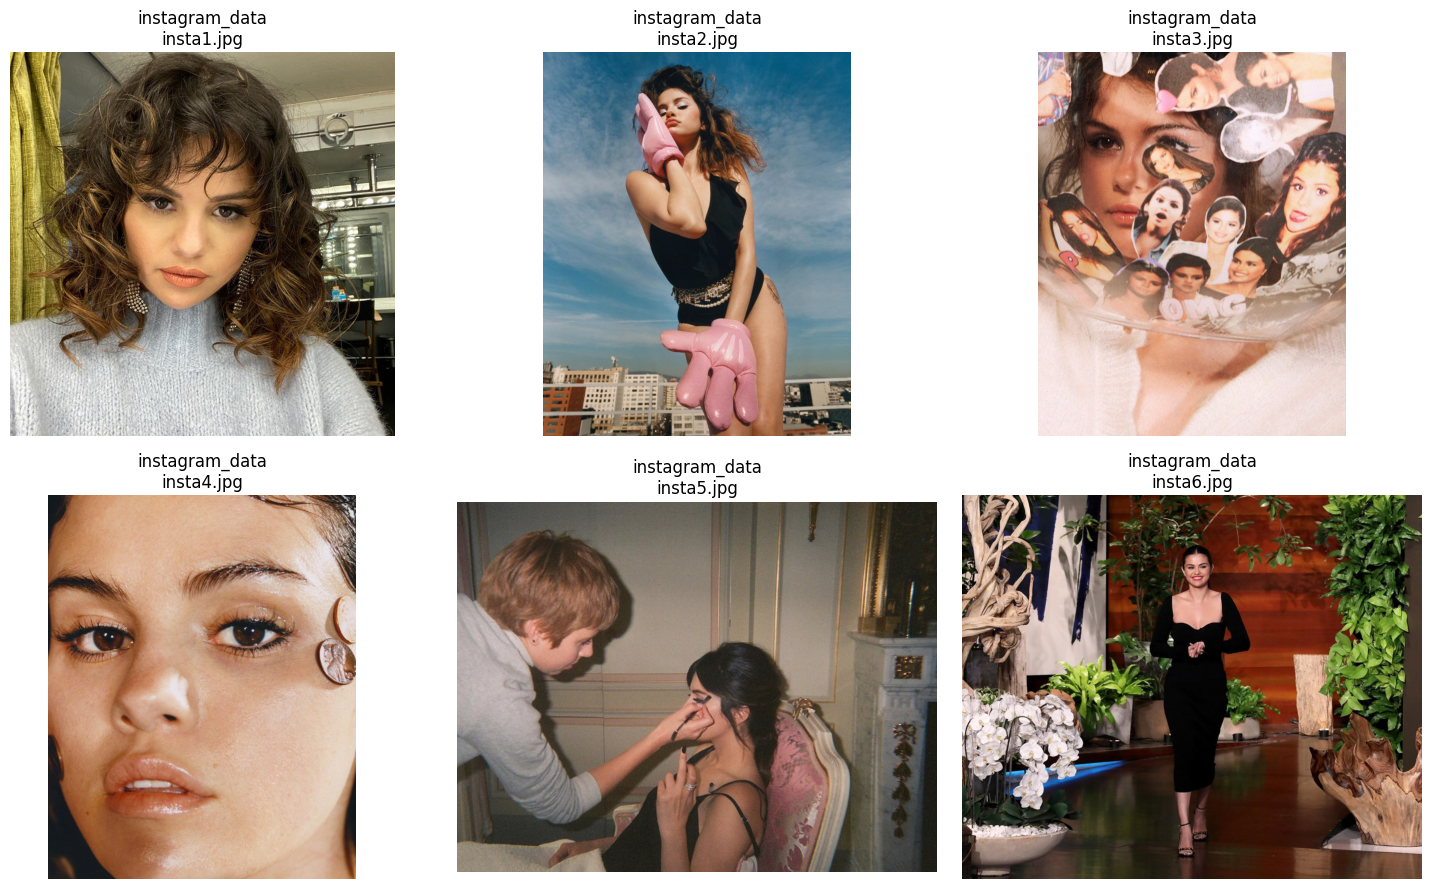

In [16]:
# ============================================================
# IMAGE SAMPLE CHECK
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt

valid_images = real_image_metadata[
    real_image_metadata["image_path"].notna()
].head(6)

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

for ax, (_, row) in zip(
    axes.flatten(),
    valid_images.iterrows()
):

    try:

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        ax.imshow(image)
        ax.set_title(
            f"{row['dataset_source']}\n"
            f"{Path(row['image_path']).name}"
        )
        ax.axis("off")

    except Exception as e:

        ax.set_title("Image error")
        ax.axis("off")

plt.tight_layout()
plt.show()